In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.integrate import quad

from label_lines import *
from matplotlib import rc, rcParams
import random
plt.rc('grid',linewidth= 2)
plt.rc('xtick.major',width=1.5)
plt.rc('xtick.major',size=8)
plt.rc('xtick.minor',width=1.5)
plt.rc('xtick.minor',size=4)
plt.rc('ytick.major',width=1.5)
plt.rc('ytick.major',size=5)
plt.rc('ytick.minor',width=1.5)
plt.rc('ytick.minor',size=2.5)
#rc('font',**{'family':'sans-serif','sans-serif':['Computer Modern Sans Serif']})
rc('xtick', labelsize=16)
rc('ytick', labelsize=16)
#Part A is -- neutral pion decay gamma rays via pp collisions
#after that secondary electrons from p-p interaction are calculated
##################
clight = 3e+10
mpiTeV = 135e-6 #  TeV
mpiGeV = 135e-3 #  GeV
GeV2TeV = 1e-3
mpGeV = 0.938      #GeV
mpTeV = 0.938e-3      #TeV
mb = 1e-27 # in cgs units

kappa= 0.17 # best agreement with num calculations ober a wide ener range of gamma rays
Kpi = 0.17
nbar = 0.86
#Input model parameter here

nH =38999
appi = clight*nH
def Fg_58TV(x, Ep):
    L = np.log(Ep) # in TeV   
    Bg = 1.3 + 0.14*L+ 0.011*L**2
    betag = 1./(1.79 + 0.11*L+ 0.008*L**2)
    kg = 1./(0.801 + 0.049*L + 0.014*L**2)
    fac1 = Bg*(np.log(x)/x)
    fac2 = pow((1-x**betag)/(1 + kg*x**betag*(1-x**betag)), 4)
    omore=  (4*kg*betag*x**betag*(1-2*x**betag))/(1 + kg*x**betag*(1- x**betag))
    fac3 = (1./np.log(x) - 4*betag*x**betag/(1-x**betag) - omore )
    return fac1*fac2*fac3

def sig_EpTV(Ep):
    mb = 1e-27 # in cgs units
    Eth = 1.e-3
    fac =  (1.- (Eth/Ep)**4)**2
    L = np.log(Ep) # in TeV
    return (34.3 + 1.88*L + 0.25* L**2)*fac*mb  #equation73   


def Jp_EpTV(Ep):   #TeV(equation80 and 74)
    E0 = 1e+3  #in TeV   
    RHS = 1 # in ergcm-3   
    RHS = 1/1.6 # in TeVcm-3
    p2 =  2.50
    p2l = 1.5
    p2u = 2.5
    LHSp2 =   integrate.quad( lambda  Ep: Ep*Ep**(-p2)*np.exp(-(Ep/E0)) ,  1, np.inf)
    Ap2 = RHS/LHSp2[0]
    return Ap2*Ep**(-p2)*np.exp(-(Ep/E0))

   

Eg_val = np.logspace(-2,2,100)   #in GeV
def eq77TV(Epi):
    
    cc1 = nbar*clight*nH/Kpi
    qpiEpi = cc1*sig_EpTV(mpTeV + Epi/ Kpi)* Jp_EpTV(mpTeV + Epi/ Kpi)
    den = np.sqrt(Epi**2 - mpiTeV**2)
    return 2*qpiEpi/den 
        
#this is for TeV scale calculation
# see the cross section effects a lower energies
Eg_f = np.logspace(-5, 3, 100)   #in TeV

fg_final = []
xval =     []
for jj in range(len(Eg_f)):
    ener =  Eg_f[jj]
    if ener < 0.1:
        
        ll = ener + mpiTeV**2/(4*ener)

        fac2 = quad(eq77TV, ll, 1.5*ll)[0] + quad(eq77TV, 1.5*ll, 50*ll)[0] + quad(eq77TV, 50*ll, np.inf)[0]
        cons1 = fac2
        xval.append(ener)
        fg_final.append(cons1)
    elif ener >= 0.1:
        fac2 = integrate.quad(lambda xx: appi*sig_EpTV(ener/xx)* Jp_EpTV(ener/xx)/xx* Fg_58TV(xx, ener/xx) , 0, 1) 

        
        xval.append(ener)
        fg_final.append(fac2[0])
        
xval     = np.array(xval)
fg_final = np.array(fg_final)


fig = plt.figure( figsize = (11.0,9))



 
kel2=  np.loadtxt('J1843DATA.csv',delimiter=",", unpack = 'True')
#print("Column 1 (X-values):", kel2[0])
#print("Column 2 (Y-values):", kel2[1])
#print("Column 3 (Errors or Additional Data):", kel2[2])
#print("Column 3:",kel2[3])


plt.loglog(kel2[0], kel2[1],'bs', label =   r'$\alpha$= 2.5')

plt.errorbar(kel2[0], kel2[1],kel2[2], kel2[3],fmt ='o')

plt.loglog(xval, xval**2*fg_final, label= 'Kelner Pion decay')





plt.legend(loc = 'upper right')
#plt.ylim(1e-19,1e-16)
plt.xlim(1e-5,1e+3)
plt.xlabel('$E_p$(TeV)')
plt.ylabel(r'(TeV $cm^{-3} s^{-1}$)')
plt.savefig('pion_decay_grays.png', dpi = 200)
plt.show()    

ModuleNotFoundError: No module named 'label_lines'

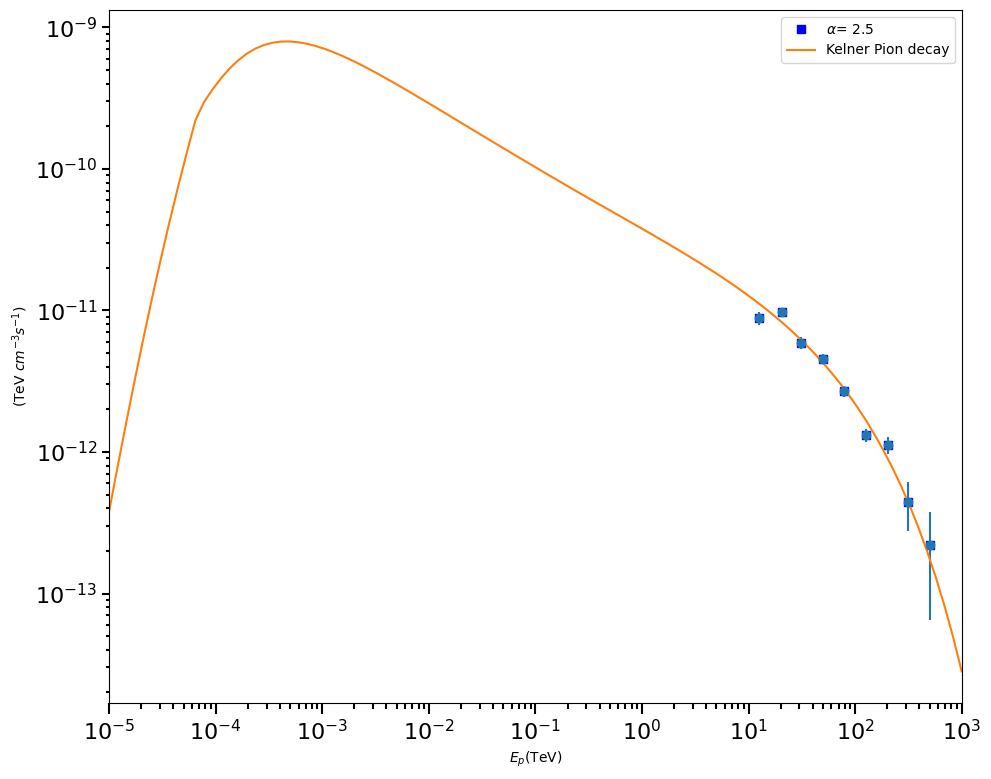

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.integrate import quad

from label_lines import *
from matplotlib import rc, rcParams 
import random
plt.rc('grid',linewidth= 2)
plt.rc('xtick.major',width=1.5)
plt.rc('xtick.major',size=8)
plt.rc('xtick.minor',width=1.5)
plt.rc('xtick.minor',size=4)
plt.rc('ytick.major',width=1.5)
plt.rc('ytick.major',size=5)
plt.rc('ytick.minor',width=1.5)
plt.rc('ytick.minor',size=2.5)
#rc('font',**{'family':'sans-serif','sans-serif':['Computer Modern Sans Serif']})
rc('xtick', labelsize=16)
rc('ytick', labelsize=16)
#Part A is -- neutral pion decay gamma rays via pp collisions
#after that secondary electrons from p-p interaction are calculated
##################
clight = 3e+10
mpiTeV = 135e-6 #  TeV
mpiGeV = 135e-3 #  GeV
GeV2TeV = 1e-3
mpGeV = 0.938      #GeV
mpTeV = 0.938e-3      #TeV
mb = 1e-27 # in cgs units

kappa= 0.17 # best agreement with num calculations ober a wide ener range of gamma rays
Kpi = 0.17
nbar = 0.86
#Input model parameter here

nH =1999999
appi = clight*nH
def Fg_58TV(x, Ep):
    L = np.log(Ep) # in TeV   
    Bg = 1.3 + 0.14*L+ 0.011*L**2
    betag = 1./(1.79 + 0.11*L+ 0.008*L**2)
    kg = 1./(0.801 + 0.049*L + 0.014*L**2)
    fac1 = Bg*(np.log(x)/x)
    fac2 = pow((1-x**betag)/(1 + kg*x**betag*(1-x**betag)), 4)
    omore=  (4*kg*betag*x**betag*(1-2*x**betag))/(1 + kg*x**betag*(1- x**betag))
    fac3 = (1./np.log(x) - 4*betag*x**betag/(1-x**betag) - omore )
    return fac1*fac2*fac3

def sig_EpTV(Ep):
    mb = 1e-27 # in cgs units
    Eth = 1.e-3
    fac =  (1.- (Eth/Ep)**4)**2
    L = np.log(Ep) # in TeV
    return (34.3 + 1.88*L + 0.25* L**2)*fac*mb  #equation73   


def Jp_EpTV(Ep):   #TeV(equation80 and 74)
    E0 = 1e+3  #in TeV   
    RHS = 1 # in ergcm-3   
    RHS = 1/1.6 # in TeVcm-3
    p2 =  2.50
    p2l = 1.5
    p2u = 2.5
    LHSp2 =   integrate.quad( lambda  Ep: Ep*Ep**(-p2)*np.exp(-(Ep/E0)) ,  1, np.inf)
    Ap2 = RHS/LHSp2[0]
    return Ap2*Ep**(-p2)*np.exp(-(Ep/E0))

   

Eg_val = np.logspace(-2,2,100)   #in GeV
def eq77TV(Epi):
    
    cc1 = nbar*clight*nH/Kpi
    qpiEpi = cc1*sig_EpTV(mpTeV + Epi/ Kpi)* Jp_EpTV(mpTeV + Epi/ Kpi)
    den = np.sqrt(Epi**2 - mpiTeV**2)
    return 2*qpiEpi/den 
        
#this is for TeV scale calculation
# see the cross section effects a lower energies
Eg_f = np.logspace(-5, 3, 100)   #in TeV

fg_final = []
xval =     []
for jj in range(len(Eg_f)):
    ener =  Eg_f[jj]
    if ener < 0.1:
        
        ll = ener + mpiTeV**2/(4*ener)

        fac2 = quad(eq77TV, ll, 1.5*ll)[0] + quad(eq77TV, 1.5*ll, 50*ll)[0] + quad(eq77TV, 50*ll, np.inf)[0]
        cons1 = fac2
        xval.append(ener)
        fg_final.append(cons1)
    elif ener >= 0.1:
        fac2 = integrate.quad(lambda xx: appi*sig_EpTV(ener/xx)* Jp_EpTV(ener/xx)/xx* Fg_58TV(xx, ener/xx) , 0, 1) 

        
        xval.append(ener)
        fg_final.append(fac2[0])
        
xval     = np.array(xval)
fg_final = np.array(fg_final)


fig = plt.figure( figsize = (11.0,9))



 
kel2=  np.loadtxt('DATAJ1908.csv',delimiter=",", unpack = 'True')
#print("Column 1 (X-values):", kel2[0])
#print("Column 2 (Y-values):", kel2[1])
#print("Column 3 (Errors or Additional Data):", kel2[2])
#print("Column 3:",kel2[3])


plt.loglog(kel2[0], kel2[1],'bs', label =   r'$\alpha$= 2.5')

plt.errorbar(kel2[0], kel2[1],kel2[2], kel2[3],fmt ='o')

plt.loglog(xval, xval**2*fg_final, label= 'Kelner Pion decay')





plt.legend(loc = 'upper right')
#plt.ylim(1e-19,1e-16)
plt.xlim(1e-5,1e+3)
plt.xlabel('$E_p$(TeV)')
plt.ylabel(r'(TeV $cm^{-3} s^{-1}$)')
plt.savefig('pion_decay_grays.png', dpi = 200)
plt.show()    